<a href="https://colab.research.google.com/github/coutinhonobre/3349-boas-praticas-java-testes-projeto/blob/main/rnn_passageiros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação - Usando Redes Recorrentes para prever séries temporais

*Nessa* avaliação, faremos uma comparação entre redes recorrentes para previsão em séries temporais. Utilizaremos tais redes  para tratar um caso de uma série temporal de número de passageiros que viajaram por mês em vôos internacionais (Atividade disponível em https://scanuto.com/rnns/  )

In [ ]:
# Importando bibliotecas
import numpy
import matplotlib.pyplot as plt
import pandas
import math
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense
from keras.layers import LSTM,  Dropout, SimpleRNN,GRU
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
numpy.random.seed(7)

In [ ]:
# Carrega apenas a coluna com o total de passageiros por mês, em milhares (112 = 122000 passageiros em vôos)
dataframe = pandas.read_csv('https://scanuto.com/rnns/seriepassageiros.csv', usecols=[1], engine='python', skipfooter=3)
dataframe.head(3)

,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,112
1,118
2,132


In [ ]:
#inclui ruído nos dados:
for i in range(len(dataframe)):
  noise = numpy.random.randint(0,500)
  dataframe.iloc[i]=dataframe.iloc[i]+noise

<Axes: >

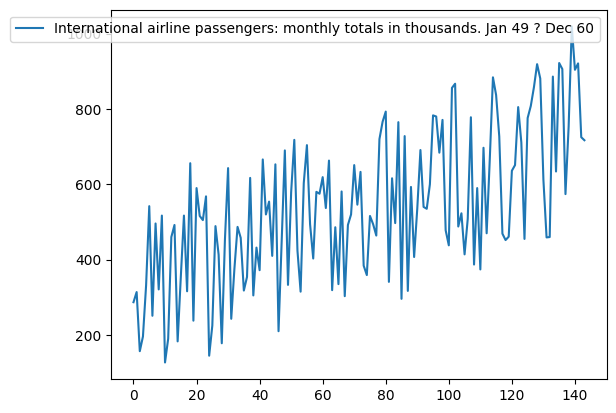

In [ ]:
dataframe.plot()

Aqui tratamos os dados que vamos usar. Dividimos os dados entre treino (67% primeiros meses) e teste (33% dos meses finais da série)

In [ ]:
#Converte a coluna do dataframe pandas em um vetor numpy
dataset = dataframe.values
dataset = dataset.astype('float32')

tamanho_janela = 60

# Divide os dados de treino (2/3) e teste (1/3)
# Note que a divisão não é aleatória, mas sim sequencial
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size-tamanho_janela-1:len(dataset),:]

Aqui formatamos nossas coleções de trenio/teste. A idéia é prever o próximo dia (Y) a partir de um segmento de tamanho tamanho_janela dos dias anteriores (X).
Portanto, criamos nossos pares de dados $X$ e $Y$, onde $Y_{t} = dataset_{t+1}$, e $X_{t}=[dataset_{t-tamanhojanela} ... dataset_{t}]$. Os dados são normalizados pela porcentagem de variação em relação ao dia atual (último dia da sequência).

In [ ]:
# Recebe uma série e converte em uma matriz de séries.
# Cada instância é um segmento, de tamanho tamanho_janela
def create_dataset(dataset, tamanho_janela):
    dataX, dataY = [], []
    for i in range(len(dataset)-tamanho_janela):
        #pega o último elemento da janela (dia de "hoje"):
        ultimo_da_janela=dataset[i+tamanho_janela-1, 0]
        #pega o primeiro elemento após a janela (dia de "amanhã"):
        proximodia=dataset[i + tamanho_janela, 0]
        #pega a porcentagem de variação entre hoje e amanhã:
        porcentagem_variacao=(proximodia-ultimo_da_janela)/ultimo_da_janela
        #anexa como o rótulo:
        dataY.append(porcentagem_variacao)

        #pega o segmento com tamanho tamanho_janela como features de entrada:
        janela = dataset[i:(i+tamanho_janela), 0]
        #normaliza todo o segmento com a porcentagem de variação:
        janela=(janela-ultimo_da_janela)/ultimo_da_janela
        dataX.append(janela)

    return numpy.array(dataX), numpy.array(dataY)

trainX, trainY = create_dataset(train, tamanho_janela)
testX, testY = create_dataset(test, tamanho_janela)

# O formato para o LSTM é [exemplos, tamanho da janela, numero de features]
# Como nossa série tem uma única feature (passageiros por mês),
# usamos o reshape para transformar os dados no formato do LSTM:
trainX = trainX.reshape(-1, tamanho_janela, 1)
testX = testX.reshape(-1, tamanho_janela, 1)

trainX.shape, testX.shape

((36, 60, 1), (49, 60, 1))

Agora criamos nossa rede RNN com 16 neurônios e janela de tamanho tamanho_janela (i.e., usa tamanho_janela pontos da série para tentar prever o próximo número) e a treinamos.

In [ ]:
opt = Adam(learning_rate=0.001)
model = Sequential()
model.add(SimpleRNN(16, input_shape=(tamanho_janela, 1), return_sequences=False))
model.add(Dense(1, activation='linear'))
model.compile(loss='mean_squared_error', optimizer=opt)
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(trainX, trainY, epochs=100, batch_size=24, validation_data=(testX, testY))

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step - loss: 0.3060 - val_loss: 0.3126
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.2454 - val_loss: 0.2807
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.2064 - val_loss: 0.2605
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1833 - val_loss: 0.2473
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1684 - val_loss: 0.2382
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.1551 - val_loss: 0.2315
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1453 - val_loss: 0.2264
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1366 - val_loss: 0.2220
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1298 - val_loss: 0.2179
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1236 - val_loss: 0.2140
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.1177 - val_loss: 0.2101
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.1126 - val

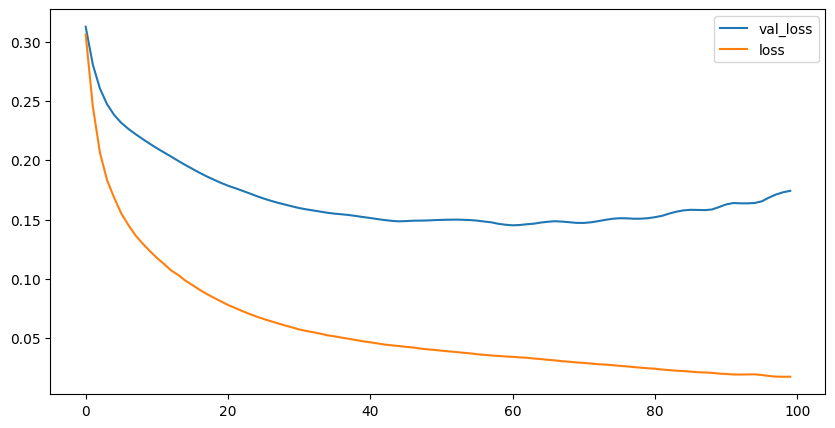

In [ ]:
df_history = pandas.DataFrame(history.history)
ax = df_history[['val_loss', 'loss']].plot(figsize=(10, 5))

In [ ]:
# Realiza as previsões. Notar que a utilidade de prever trainX é nenhuma. Serve apenas para exibir no gráfico.
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


Ao final das previsões, reescalonamos os dados para a escala original e calculamos as métricas de RMSE.

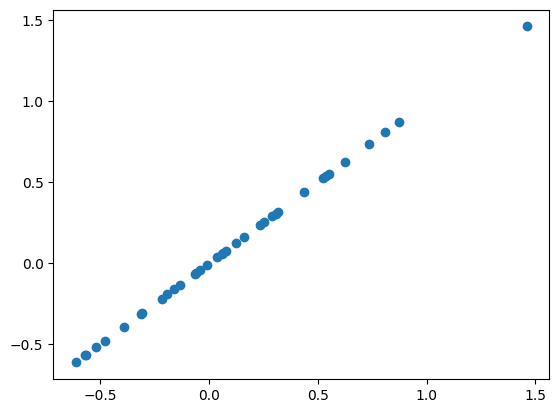

In [ ]:
#resultado esperado:
plt.scatter(trainY, trainY)

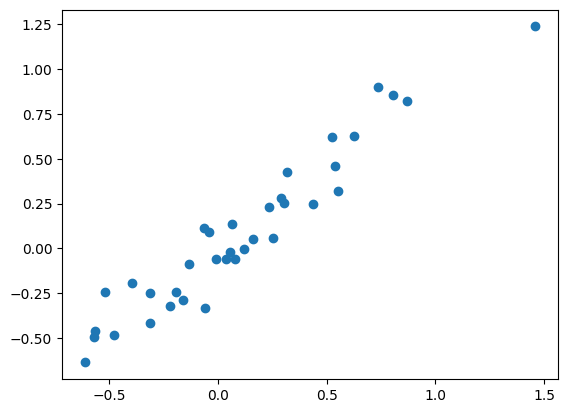

In [ ]:
#resultado obtido (modelo nos dados de treino):
plt.scatter(trainY, trainPredict.ravel())

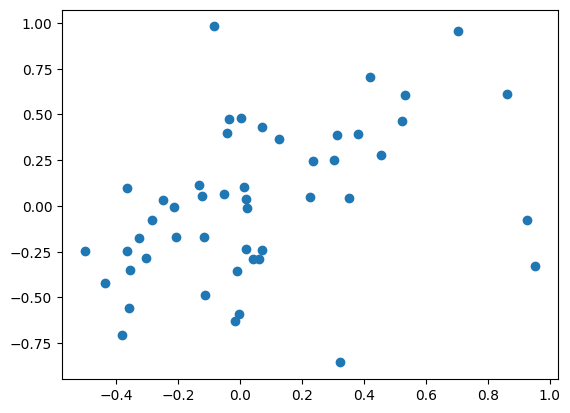

In [ ]:
#resultado obtido (modelo nos dados de teste)
plt.scatter(testY, testPredict.ravel())

In [ ]:
# Calcula os erros de previsão
trainScore = math.sqrt(mean_squared_error(trainY, trainPredict[:,0]))
print('Train Score: %.2f MSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY, testPredict[:,0]))
print('Test Score: %.2f MSE' % (testScore))

Train Score: 0.13 MSE
Test Score: 0.42 MSE
